
# Khipus.ai
## Introduction to Machine Learning
### Data Preparation
<span>© Copyright Notice 2025, Khipus.ai - All Rights Reserved.</span>

### Classification
### Logistic Regression
### Assignment 3
### Name: Gabriel Severiche


## Instructions:
----------------------------
1. Perform **data exploration**, **data cleaning**, **feature selection**, and **splitting training and test data** (Credit_card_Approval.csv).
2. Build the **logistic regression model**.
3. Make **predictions**.
4. Evaluate the model's performance using metrics like **accuracy, precision, recall, and F1 score**.
5. Visualize the results, such as plotting the  **confusion matrix** and **ROC curve** 


### Step 1: Data Exploration

In [51]:
# Load necessary libraries
import pandas as pd

# Load the dataset
data = pd.read_csv('Credit_card_Approval.csv')

# Explore the data
data.head()

,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,Approved
0,5008827,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,-18772.0,365243,1,0,0,0,NaN,2,1
1,5009744,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1
2,5009746,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,NaN,-586,1,1,1,0,NaN,2,1
3,5009749,F,Y,N,0,NaN,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1
4,5009752,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1


In [52]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1548 entries, 0 to 1547
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Ind_ID           1548 non-null   int64  
 1   GENDER           1541 non-null   str    
 2   Car_Owner        1548 non-null   str    
 3   Propert_Owner    1548 non-null   str    
 4   CHILDREN         1548 non-null   int64  
 5   Annual_income    1525 non-null   float64
 6   Type_Income      1548 non-null   str    
 7   EDUCATION        1548 non-null   str    
 8   Marital_status   1548 non-null   str    
 9   Housing_type     1548 non-null   str    
 10  Birthday_count   1526 non-null   float64
 11  Employed_days    1548 non-null   int64  
 12  Mobile_phone     1548 non-null   int64  
 13  Work_Phone       1548 non-null   int64  
 14  Phone            1548 non-null   int64  
 15  EMAIL_ID         1548 non-null   int64  
 16  Type_Occupation  1060 non-null   str    
 17  Family_Members   1548 non

In [53]:
data.describe()

,Ind_ID,CHILDREN,Annual_income,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Family_Members,Approved
count,1.548000e+03,1548.000000,1.525000e+03,1526.000000,1548.000000,1548.0,1548.000000,1548.000000,1548.000000,1548.000000,1548.000000
mean,5.078920e+06,0.412791,1.913993e+05,-16040.342071,59364.689922,1.0,0.208010,0.309432,0.092377,2.161499,0.113049
std,4.171759e+04,0.776691,1.132530e+05,4229.503202,137808.062701,0.0,0.406015,0.462409,0.289651,0.947772,0.316755
min,5.008827e+06,0.000000,3.375000e+04,-24946.000000,-14887.000000,1.0,0.000000,0.000000,0.000000,1.000000,0.000000
25%,5.045070e+06,0.000000,1.215000e+05,-19553.000000,-3174.500000,1.0,0.000000,0.000000,0.000000,2.000000,0.000000
50%,5.078842e+06,0.000000,1.665000e+05,-15661.500000,-1565.000000,1.0,0.000000,0.000000,0.000000,2.000000,0.000000
75%,5.115673e+06,1.000000,2.250000e+05,-12417.000000,-431.750000,1.0,0.000000,1.000000,0.000000,3.000000,0.000000
max,5.150412e+06,14.000000,1.575000e+06,-7705.000000,365243.000000,1.0,1.000000,1.000000,1.000000,15.000000,1.000000


### Step 2: Data Cleaning and Feature Selection

In [54]:
# Handle missing values, duplicates, and irrelevant features
missing_values = data.isnull().sum()
print(missing_values)
# Convert categorical data to numeric using one-hot encoding if needed
# Display cleaned data


Ind_ID               0
GENDER               7
Car_Owner            0
Propert_Owner        0
CHILDREN             0
Annual_income       23
Type_Income          0
EDUCATION            0
Marital_status       0
Housing_type         0
Birthday_count      22
Employed_days        0
Mobile_phone         0
Work_Phone           0
Phone                0
EMAIL_ID             0
Type_Occupation    488
Family_Members       0
Approved             0
dtype: int64


In [55]:
data = data.dropna()  # Remove rows with missing values
data = data.drop_duplicates()  # Remove duplicates
data =pd.get_dummies(data, drop_first=True)  # Convert categorical variables to dummy variables 
data.head()


,Ind_ID,CHILDREN,Annual_income,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Family_Members,...,Type_Occupation_Laborers,Type_Occupation_Low-skill Laborers,Type_Occupation_Managers,Type_Occupation_Medicine staff,Type_Occupation_Private service staff,Type_Occupation_Realty agents,Type_Occupation_Sales staff,Type_Occupation_Secretaries,Type_Occupation_Security staff,Type_Occupation_Waiters/barmen staff
8,5010864,1,450000.0,-18173.0,-678,1,0,1,1,3,...,False,False,False,False,False,False,False,False,False,False
9,5010868,1,450000.0,-18173.0,-678,1,0,1,1,3,...,False,False,False,False,False,False,False,False,False,False
10,5010869,1,450000.0,-18173.0,-678,1,0,1,1,1,...,False,False,False,False,False,False,False,False,False,False
11,5018498,0,90000.0,-18950.0,-1002,1,1,1,0,2,...,False,False,False,False,False,False,False,False,False,False
13,5018503,0,90000.0,-18950.0,-1002,1,1,1,0,2,...,False,False,False,False,False,False,False,False,False,False


In [56]:
missing_values = data.isnull().sum()
print(missing_values)

Ind_ID                                     0
CHILDREN                                   0
Annual_income                              0
Birthday_count                             0
Employed_days                              0
Mobile_phone                               0
Work_Phone                                 0
Phone                                      0
EMAIL_ID                                   0
Family_Members                             0
Approved                                   0
GENDER_M                                   0
Car_Owner_Y                                0
Propert_Owner_Y                            0
Type_Income_Pensioner                      0
Type_Income_State servant                  0
Type_Income_Working                        0
EDUCATION_Incomplete higher                0
EDUCATION_Lower secondary                  0
EDUCATION_Secondary / secondary special    0
Marital_status_Married                     0
Marital_status_Separated                   0
Marital_st

### Step 3: Splitting Training and Test Data

In [57]:
from sklearn.model_selection import train_test_split

# Define features and target
X = data.drop('Approved', axis=1)  # Features
y = data['Approved']  # Target variable

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### Step 4: Build the Logistic Regression Model

In [58]:
from sklearn.linear_model import LogisticRegression

# Initialize the model
model = LogisticRegression()
# Train the model
model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

### Step 5: Make Predictions

In [59]:
# Make predictions on the test set
predictions = model.predict(X_test)

### Step 6: Evaluate the Model

Expected output:

Accuracy: 0.87
Classification Report:
              precision    recall  f1-score   support

           0       0.87      1.00      0.93       269
           1       0.00      0.00      0.00        39

    accuracy                           0.87       308
   macro avg       0.44      0.50      0.47       308
weighted avg       0.76      0.87      0.81       308

In [60]:
from sklearn.metrics import accuracy_score, classification_report

# Calculate accuracy
accuracy = accuracy_score(y_test, predictions)

# Display classification report with zero_division parameter
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:")
print(classification_report(y_test, predictions, zero_division=0))


Accuracy: 0.88
Classification Report:
              precision    recall  f1-score   support

           0       0.88      1.00      0.94       180
           1       0.00      0.00      0.00        25

    accuracy                           0.88       205
   macro avg       0.44      0.50      0.47       205
weighted avg       0.77      0.88      0.82       205



### Step 7: Visualize the Results

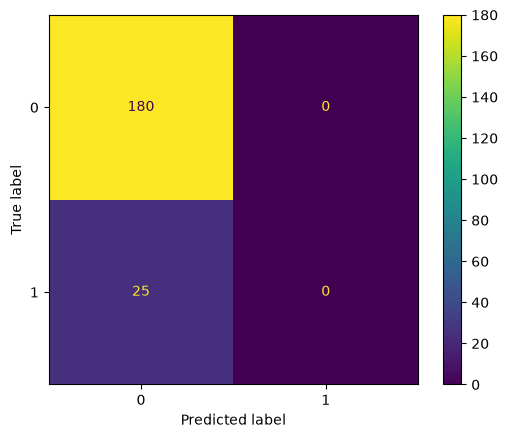

In [61]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate the confusion matrix
cm = confusion_matrix(y_test, predictions)
# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

### # Plot the ROC curve

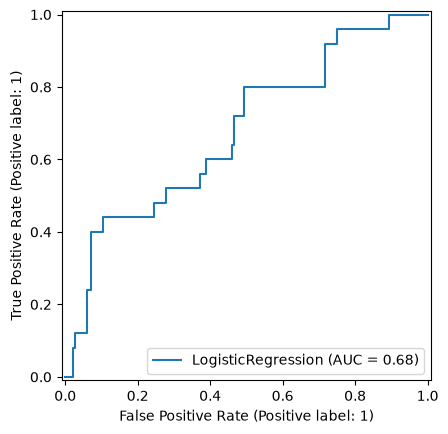

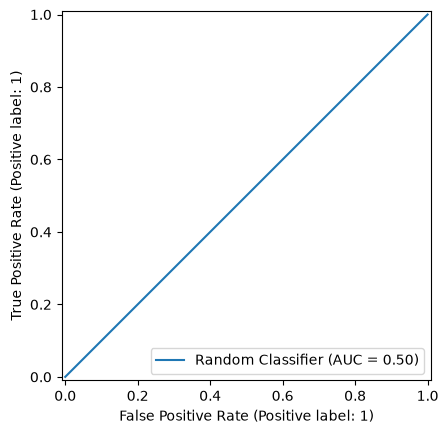

In [62]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

# Plot the ROC curve
curva = RocCurveDisplay.from_estimator(model, X_test, y_test)
# Plot the ROC curve for the random classifier
curva.from_predictions(y_test, [0.5] * len(y_test), name="Random Classifier")

